# GOTISHEEL TECHNOLOGIES TASK-1

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [46]:
df = pd.read_csv("industrial_safety_events_dataset.csv")


In [47]:
df.head()

,_id,client_id,id,camera,frame_time,snapshot_frame_time,snapshot_box_x1,snapshot_box_y1,snapshot_box_x2,snapshot_box_y2,...,entered_zones,has_clip,has_snapshot,location,zone,unit,created_at,status,remarks,__v
0,cbf2dd4ccced4e5c9f31ed57,fcf2a3d7a876e08e40ae222d,5a51ae79-5a9b-441e-85d7-cd849961b9d9,cam7_848480916e9787356f008942,1.779436e+09,1.779436e+09,897,20,323,147,...,Control Room,True,True,2c432a2a31a3448437bcbd2d,Assembly Zone,Unit-D,2026-05-22T07:53:29.386566,open,Supervisor notified,0
1,605711a8584046ee8929edd0,efecfd93b4c0ce7ae5173970,1d3f5e17-713b-4a8a-bb6b-faa5ec92794a,cam12_a2a713b2aeae3a7e2bbc1acc,1.778848e+09,1.778848e+09,892,650,990,627,...,Packing Unit,False,True,4bf5b12a1bb847bc0bf619b8,Control Room,Unit-A,2026-05-15T12:25:30.386889,resolved,Monitoring ongoing,0
2,8c29b00d521e2ddd24f6eda0,aa0ea1eda6b7cd4e09fe6cd2,7b83e977-38d1-4819-bd71-a1c3913b4591,cam3_3dd3f46fc99f6c90b4913b00,1.779048e+09,1.779048e+09,565,365,261,254,...,Control Room,False,True,f8cd85b192b6f75a56ea227e,Control Room,Unit-B,2026-05-17T20:02:51.387263,open,Monitoring ongoing,0
3,e7c57dd3f76509fdfb9bfa5b,2bb2268b544854738463e8ff,2a0f16d9-5464-4553-aca1-2c9e5df358be,cam11_03c5a4c3481c84dbbb71a94a,1.779466e+09,1.779466e+09,1138,345,1214,578,...,Assembly Zone,False,True,6ffcf9945113f5fc2e75e46a,Boiler Room,Unit-D,2026-05-22T16:06:52.387715,resolved,Supervisor notified,0
4,39a3e6ff6b82c73d86a25eb4,e84458b2afcc88867cd05591,bdbd8cb1-8af2-4fbd-a728-fd56f3d00cd8,cam4_aa95758165c26aa360c2bc14,1.779218e+09,1.779218e+09,140,280,146,557,...,Control Room,True,True,9b285e6a4bbab4bdfeac9179,Assembly Zone,Unit-C,2026-05-19T19:05:48.387880,open,Escalated to safety team,0


In [48]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1300, 47)


In [49]:
df.columns

Index(['_id', 'client_id', 'id', 'camera', 'frame_time', 'snapshot_frame_time',
       'snapshot_box_x1', 'snapshot_box_y1', 'snapshot_box_x2',
       'snapshot_box_y2', 'snapshot_area', 'snapshot_region_x1',
       'snapshot_region_y1', 'snapshot_region_x2', 'snapshot_region_y2',
       'snapshot_score', 'label', 'sub_label', 'top_score', 'false_positive',
       'start_time', 'end_time', 'score', 'box_x1', 'box_y1', 'box_x2',
       'box_y2', 'area', 'ratio', 'region_x1', 'region_y1', 'region_x2',
       'region_y2', 'stationary', 'motionless_count', 'position_changes',
       'current_zones', 'entered_zones', 'has_clip', 'has_snapshot',
       'location', 'zone', 'unit', 'created_at', 'status', 'remarks', '__v'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   _id                  1300 non-null   object 
 1   client_id            1300 non-null   object 
 2   id                   1300 non-null   object 
 3   camera               1300 non-null   object 
 4   frame_time           1300 non-null   float64
 5   snapshot_frame_time  1300 non-null   float64
 6   snapshot_box_x1      1300 non-null   int64  
 7   snapshot_box_y1      1300 non-null   int64  
 8   snapshot_box_x2      1300 non-null   int64  
 9   snapshot_box_y2      1300 non-null   int64  
 10  snapshot_area        1300 non-null   int64  
 11  snapshot_region_x1   1300 non-null   int64  
 12  snapshot_region_y1   1300 non-null   int64  
 13  snapshot_region_x2   1300 non-null   int64  
 14  snapshot_region_y2   1300 non-null   int64  
 15  snapshot_score       1300 non-null   f

In [51]:
df.isnull().sum()

_id                       0
client_id                 0
id                        0
camera                    0
frame_time                0
snapshot_frame_time       0
snapshot_box_x1           0
snapshot_box_y1           0
snapshot_box_x2           0
snapshot_box_y2           0
snapshot_area             0
snapshot_region_x1        0
snapshot_region_y1        0
snapshot_region_x2        0
snapshot_region_y2        0
snapshot_score            0
label                     0
sub_label              1300
top_score                 0
false_positive            0
start_time                0
end_time                  0
score                     0
box_x1                    0
box_y1                    0
box_x2                    0
box_y2                    0
area                      0
ratio                     0
region_x1                 0
region_y1                 0
region_x2                 0
region_y2                 0
stationary                0
motionless_count          0
position_changes    

In [52]:
df['created_at'] = pd.to_datetime(df['created_at'])

# CREATE KPI METRICS

In [53]:
total_events = len(df)

total_cameras = df['camera'].nunique()

total_zones = df['zone'].nunique()

total_labels = df['label'].nunique()

average_confidence = df['score'].mean()

print("Total Events:", total_events)
print("Total Cameras:", total_cameras)
print("Total Zones:", total_zones)
print("Total Labels:", total_labels)
print("Average Confidence:", round(average_confidence,2))

Total Events: 1300
Total Cameras: 1300
Total Zones: 6
Total Labels: 20
Average Confidence: 0.74


# EVENT DISTRIBUTION ANALYSIS

In [54]:
label_counts = df['label'].value_counts()

label_counts

label
without_glove      80
without_helmet     75
loitering          74
nomask             73
without_goggle     72
smoke              70
crowd              70
no_ifr             67
license_plate      67
fall               65
no_harness         64
fire               64
smoker             63
without_boot       62
hairnet            60
cell_phone         58
person             57
nohairnet          54
no_extinguisher    53
mask               52
Name: count, dtype: int64

In [55]:
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    title="Event Count Per Label",
    labels={
        'x':'Violation Type',
        'y':'Count'
    },
    color=label_counts.values
)

fig.show()

# PIE CHART OF VIOLATIONS

In [56]:
fig = px.pie(
    values=label_counts.values,
    names=label_counts.index,
    title="Violation Distribution"
)

fig.show()

# CAMERA-WISE VIOLATIONS

In [57]:
camera_counts = df['camera'].value_counts().head(10)

camera_counts

camera
cam7_848480916e9787356f008942     1
cam12_874daaafa356575c5abbed57    1
cam11_04ad7454eae7e9e9c27b0e92    1
cam7_a5b7acb392cc19950fb2dfb0     1
cam6_0654dcff922b5c76049e34e7     1
cam6_30cddcdc3d49873ecc02eb13     1
cam3_08452baf6cc03398da4bfa98     1
cam7_2e97cb55079ee536f3785897     1
cam3_d68bb174a720840491cc0857     1
cam6_bddecfa5d001fe3199b87e96     1
Name: count, dtype: int64

In [58]:
fig = px.bar(
    x=camera_counts.index,
    y=camera_counts.values,
    title="Top 10 Cameras with Maximum Violations",
    labels={
        'x':'Camera',
        'y':'Violations'
    },
    color=camera_counts.values
)

fig.show()

# ZONE-WISE INCIDENTS

In [59]:
zone_counts = df['zone'].value_counts()

zone_counts

zone
Warehouse        250
Boiler Room      221
Control Room     215
Loading Bay      210
Packing Unit     204
Assembly Zone    200
Name: count, dtype: int64

In [60]:
fig = px.bar(
    x=zone_counts.index,
    y=zone_counts.values,
    title="Zone-wise Incidents",
    color=zone_counts.values
)

fig.show()

# EVENT TREND OVER TIME

In [61]:
daily_events = df.groupby(df['created_at'].dt.date).size()

daily_events

created_at
2026-04-26    10
2026-04-27    47
2026-04-28    63
2026-04-29    40
2026-04-30    43
2026-05-01    45
2026-05-02    43
2026-05-03    44
2026-05-04    41
2026-05-05    41
2026-05-06    50
2026-05-07    42
2026-05-08    47
2026-05-09    45
2026-05-10    36
2026-05-11    49
2026-05-12    49
2026-05-13    37
2026-05-14    51
2026-05-15    42
2026-05-16    36
2026-05-17    44
2026-05-18    30
2026-05-19    34
2026-05-20    47
2026-05-21    42
2026-05-22    41
2026-05-23    44
2026-05-24    53
2026-05-25    32
2026-05-26    32
dtype: int64

In [62]:
fig = px.line(
    x=daily_events.index,
    y=daily_events.values,
    title="Daily Event Trend"
)

fig.show()

# HOURLY ANALYSIS

In [63]:
df['hour'] = df['created_at'].dt.hour

In [64]:
hourly_events = df.groupby('hour').size()

hourly_events

hour
0     56
1     49
2     60
3     62
4     58
5     53
6     43
7     68
8     58
9     48
10    58
11    57
12    65
13    52
14    53
15    54
16    54
17    39
18    58
19    53
20    41
21    53
22    55
23    53
dtype: int64

In [65]:
fig = px.line(
    x=hourly_events.index,
    y=hourly_events.values,
    title="Hourly Violation Trend",
    labels={
        'x':'Hour',
        'y':'Events'
    }
)

fig.show()

# SAFETY COMPLIANCE ANALYSIS

In [66]:
safe_labels = ['mask', 'hairnet', 'person']

df['compliance'] = df['label'].apply(
    lambda x: 'Compliant' if x in safe_labels else 'Violation'
)

In [67]:
compliance_counts = df['compliance'].value_counts()

compliance_counts

compliance
Violation    1131
Compliant     169
Name: count, dtype: int64

In [68]:
fig = px.pie(
    values=compliance_counts.values,
    names=compliance_counts.index,
    title="Safety Compliance Percentage"
)

fig.show()

# HIGH RISK EVENTS

In [69]:
high_risk = df[
    df['label'].isin(['fire', 'smoke', 'fall'])
]

In [70]:
high_risk['label'].value_counts()

label
smoke    70
fall     65
fire     64
Name: count, dtype: int64

In [71]:
risk_counts = high_risk['label'].value_counts()

fig = px.bar(
    x=risk_counts.index,
    y=risk_counts.values,
    title="High Risk Safety Events",
    color=risk_counts.values
)

fig.show()

# CORRELATION HEATMAP

In [72]:
numeric_cols = [
    'score',
    'top_score',
    'motionless_count',
    'position_changes',
    'area'
]

In [73]:
corr = df[numeric_cols].corr()

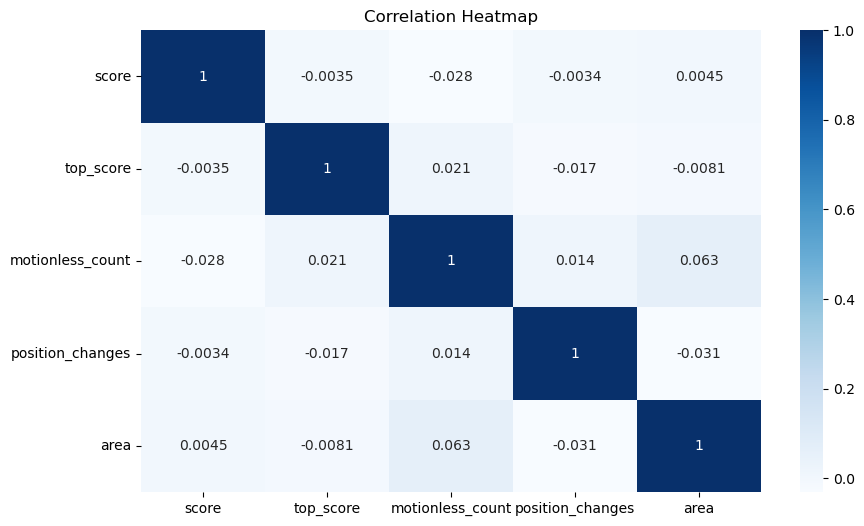

In [74]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# MOST RECURRING VIOLATION

In [75]:
most_common_violation = df['label'].value_counts().idxmax()

count = df['label'].value_counts().max()

print("Most Recurring Violation:", most_common_violation)
print("Count:", count)

Most Recurring Violation: without_glove
Count: 80


# CAMERA WITH MAXIMUM VIOLATIONS

In [76]:
top_camera = df['camera'].value_counts().idxmax()

camera_count = df['camera'].value_counts().max()

print("Camera with Maximum Violations:", top_camera)
print("Violation Count:", camera_count)

Camera with Maximum Violations: cam7_848480916e9787356f008942
Violation Count: 1


# MOST UNSAFE ZONE

In [77]:
top_zone = df['zone'].value_counts().idxmax()

zone_count = df['zone'].value_counts().max()

print("Most Unsafe Zone:", top_zone)
print("Incident Count:", zone_count)

Most Unsafe Zone: Warehouse
Incident Count: 250


# PEAK VIOLATION HOUR

In [78]:
peak_hour = df['hour'].value_counts().idxmax()

peak_count = df['hour'].value_counts().max()

print("Peak Violation Hour:", peak_hour)
print("Event Count:", peak_count)

Peak Violation Hour: 7
Event Count: 68


# FIRE & SMOKE ANALYSIS

In [79]:
fire_smoke = df[df['label'].isin(['fire', 'smoke'])]

print("Total Fire/Smoke Events:", len(fire_smoke))

print(fire_smoke['label'].value_counts())

Total Fire/Smoke Events: 134
label
smoke    70
fire     64
Name: count, dtype: int64


# PROFESSIONAL ANALYTICS VISUALS + BUSINESS INSIGHTS

In [80]:
false_positive_counts = df['false_positive'].value_counts()

false_positive_counts

false_positive
True     665
False    635
Name: count, dtype: int64

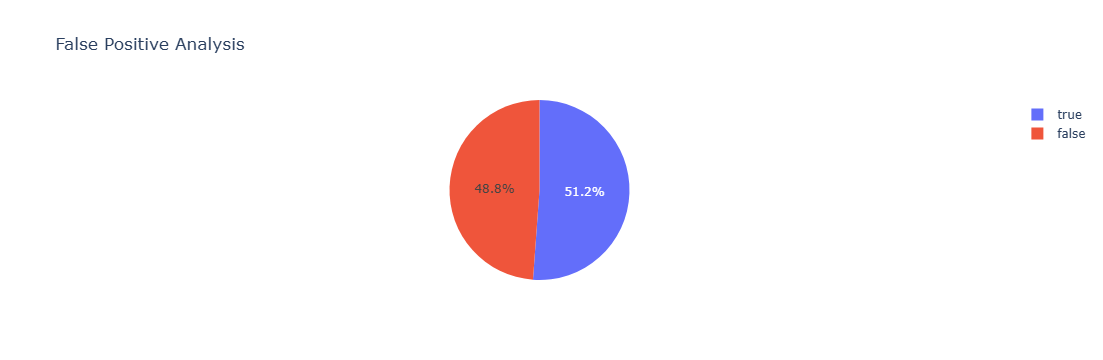

In [81]:
fig = px.pie(
    values=false_positive_counts.values,
    names=false_positive_counts.index,
    title="False Positive Analysis"
)

fig.show()

In [82]:
fig = px.histogram(
    df,
    x='score',
    nbins=30,
    title='Detection Confidence Score Distribution'
)

fig.show()

In [83]:
df['event_duration'] = df['end_time'] - df['start_time']

In [84]:
fig = px.box(
    df,
    y='event_duration',
    title='Event Duration Analysis'
)

fig.show()

In [85]:
top_violations = df['label'].value_counts().head(10)

fig = px.bar(
    x=top_violations.index,
    y=top_violations.values,
    title='Top 10 Recurring Violations',
    color=top_violations.values
)

fig.show()

In [86]:
fig = px.scatter(
    df,
    x='motionless_count',
    y='position_changes',
    color='label',
    title='Motion vs Position Change Analysis'
)

fig.show()

In [87]:
unsafe_cameras = df['camera'].value_counts().reset_index()

unsafe_cameras.columns = ['Camera', 'Violations']

unsafe_cameras.head(10)

,Camera,Violations
0,cam7_848480916e9787356f008942,1
1,cam12_874daaafa356575c5abbed57,1
2,cam11_04ad7454eae7e9e9c27b0e92,1
3,cam7_a5b7acb392cc19950fb2dfb0,1
4,cam6_0654dcff922b5c76049e34e7,1
5,cam6_30cddcdc3d49873ecc02eb13,1
6,cam3_08452baf6cc03398da4bfa98,1
7,cam7_2e97cb55079ee536f3785897,1
8,cam3_d68bb174a720840491cc0857,1
9,cam6_bddecfa5d001fe3199b87e96,1


In [88]:
unsafe_zones = df['zone'].value_counts().reset_index()

unsafe_zones.columns = ['Zone', 'Incidents']

unsafe_zones.head()

,Zone,Incidents
0,Warehouse,250
1,Boiler Room,221
2,Control Room,215
3,Loading Bay,210
4,Packing Unit,204


# Key Business Insights

- The dataset contains surveillance events across multiple cameras and industrial zones.

- PPE-related violations were among the most frequently detected incidents.

- Certain cameras consistently captured higher unsafe activity, indicating high-risk monitoring areas.

- Violation activity showed hourly peaks, helping identify unsafe operational periods.

- Fire and smoke incidents were lower in frequency but categorized as critical-risk events.

- Detection confidence scores remained consistently high across most surveillance events.

# Industrial Safety Surveillance Analytics

This project analyzes industrial surveillance event data generated from an AI-based safety monitoring system. The analysis focuses on violation trends, compliance monitoring, camera analytics, zone-based risk assessment, and operational safety insights.